# Quantum and Classical Preconditioning Analysis

Sections, in order: approximation ratio, PAR-based ε-hit bar charts, a combined
ε=0/ε=1% PAR line plot (presolve enabled vs disabled side by side), a
single-seed MIPSol trajectory plot, per-family (quantum/classical) scaling
across problem sizes, a penalty-strategy comparison grid (Oracle upper-bound vs.
cross-validated ρ selection, presolve enabled vs disabled), one combined
quantum/classical scaling comparison, and a performance-distribution plot
(final solution quality vs. the classical baseline, per QAOA depth). Each
section is repeated for the quantum and classical preconditioner families where
applicable.


In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "qp_gurobi").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import qp_gurobi.utils as qutils
qutils = importlib.reload(qutils)

PlotConfig = qutils.PlotConfig
apply_plot_style = qutils.apply_plot_style
compute_hit_time_plot_limits = qutils.compute_hit_time_plot_limits
load_family_comparison_data = qutils.load_family_comparison_data
load_family_comparison_trajectory_data = qutils.load_family_comparison_trajectory_data
load_quantum_infinite_depth_comparison_data = qutils.load_quantum_infinite_depth_comparison_data
load_summary_data = qutils.load_summary_data
load_trajectory_data = qutils.load_trajectory_data
plot_family_param_comparison = qutils.plot_family_param_comparison
plot_hit_time_vs_penalty = qutils.plot_hit_time_vs_penalty
plot_hit_time_lines = qutils.plot_hit_time_lines
plot_hit_time_lines_side_by_side_presolve = qutils.plot_hit_time_lines_side_by_side_presolve
plot_mipsol_ratio_minus_one = qutils.plot_mipsol_ratio_minus_one
plot_quantum_vs_classical_comparison = qutils.plot_quantum_vs_classical_comparison
plot_layer_comparison_panel_strategies = qutils.plot_layer_comparison_panel_strategies
plot_layer_comparison_grid = qutils.plot_layer_comparison_grid
plot_layer_comparison_grid_by_presolve = qutils.plot_layer_comparison_grid_by_presolve
plot_layer_comparison_side_by_side_presolve = qutils.plot_layer_comparison_side_by_side_presolve
plot_ratio_minus_one = qutils.plot_ratio_minus_one
prepare_hit_time_metrics = qutils.prepare_hit_time_metrics
prepare_penalty_metrics = qutils.prepare_penalty_metrics
plot_performance_distribution = qutils.plot_performance_distribution

apply_plot_style()

N = 40          # problem size for quantum single-seed analysis
CLASSICAL_N = 28  # largest N with classical data currently available
PRESOLVE = True
THRESHOLDS_TO_PLOT = [0.0, 0.001, 0.01]
LINE_EPS_THRESHOLDS = [0.0, 0.01]  # combined line plot only wants eps=0 and eps=1%
PENALTY_FILTER = None
TRAJ_PENALTY_FILTER = [round(x * 0.1, 3) for x in range(0, 13)]  # trajectory plots only: rho in [0.0, 1.2]
LOG_TIME_AXIS = True
PAR_FACTOR = 1.0
# Merged full-range sweeps + penalty-restricted (1.1-2.0) cluster runs; rebuild
# with scripts/merge_penalty_results.py whenever more cluster data lands.
RESULTS_DIR = REPO_ROOT / "results" / "merged"
TRAJ_SEED = 20
MIPSOL_VALUE_COL = "orig_obj"  # or "running_best_orig_obj"
COMPARE_METRIC = "time_to_best_sec"  # or "runtime_sec"

# Approximation threshold for the scaling plot.
# 0.01 = find a solution within 1% of the baseline optimum.
EPS_THRESHOLD = 0.01

QUANTUM_LAYER = 1
CLASSICAL_SWEEP = 100
QUANTUM_LAYERS = [1, 2, 3]
CLASSICAL_SWEEPS = [10, 100, 1000, 10000]
INCLUDE_P_INF = True

# N=8 is intentionally excluded: at this size the preconditioned instance's
# time-to-1%-optimal is anomalously large relative to N=12 (verified via raw
# Gurobi runtime_sec, not just the trajectory-derived hit time; baseline scales
# normally at N=8 so it isn't a hardware/overhead artifact). Most likely a
# small-N symmetry/degeneracy effect, not representative of the asymptotic
# scaling trend these plots are meant to show.
QUANTUM_SCALING_SIZES_ON  = [12, 16, 20, 24, 28, 32, 36, 40]
QUANTUM_SCALING_SIZES_OFF = [12, 16, 20, 24, 28, 32, 36, 40]
# Classical runs complete through N=32 (sweeps=10/100); update when larger runs finish.
CLASSICAL_SCALING_SIZES_ON  = [12, 16, 20, 24, 28, 32]
CLASSICAL_SCALING_SIZES_OFF = [12, 16, 20, 24, 28, 32]

QUANTUM_SCALING_SIZES  = QUANTUM_SCALING_SIZES_ON  if PRESOLVE else QUANTUM_SCALING_SIZES_OFF
CLASSICAL_SCALING_SIZES = CLASSICAL_SCALING_SIZES_ON if PRESOLVE else CLASSICAL_SCALING_SIZES_OFF
QUANTUM_COMPARE_PARAMS = QUANTUM_LAYERS + ([float("inf")] if INCLUDE_P_INF else [])

quantum_cfg   = PlotConfig(n=N,           family="quantum",    layers=QUANTUM_LAYER)
classical_cfg = PlotConfig(n=CLASSICAL_N, family="classical",  sweeps=CLASSICAL_SWEEP)
presolve_label = "presolve enabled" if PRESOLVE else "presolve disabled"

print(f"Using {presolve_label}.")
print(f"Quantum setting: p={QUANTUM_LAYER}  (N={N})")
print(f"Classical setting: s={CLASSICAL_SWEEP}  (N={CLASSICAL_N})")
print(f"Include p=inf in quantum scaling comparison: {INCLUDE_P_INF}")
print(f"Scaling plot threshold: {EPS_THRESHOLD * 100:g}%-optimal")
utils_path = Path(qutils.__file__).resolve().relative_to(REPO_ROOT)
print(f"Loaded utils from: {utils_path}")


%load_ext autoreload
%autoreload 2

Using presolve enabled.
Quantum setting: p=1  (N=40)
Classical setting: s=100  (N=28)
Include p=inf in quantum scaling comparison: True
Scaling plot threshold: 1%-optimal
Loaded utils from: qp_gurobi/utils.py


## Quantum Penalty Analysis


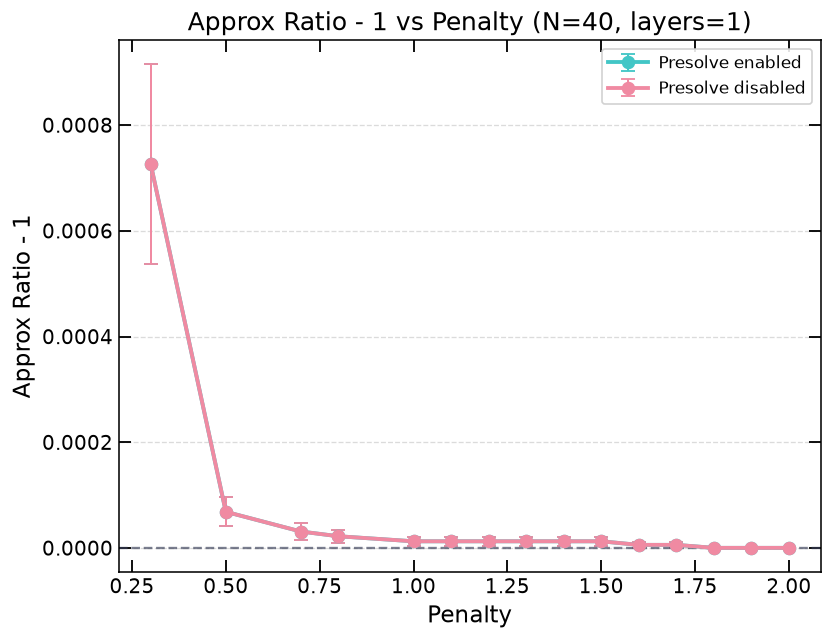

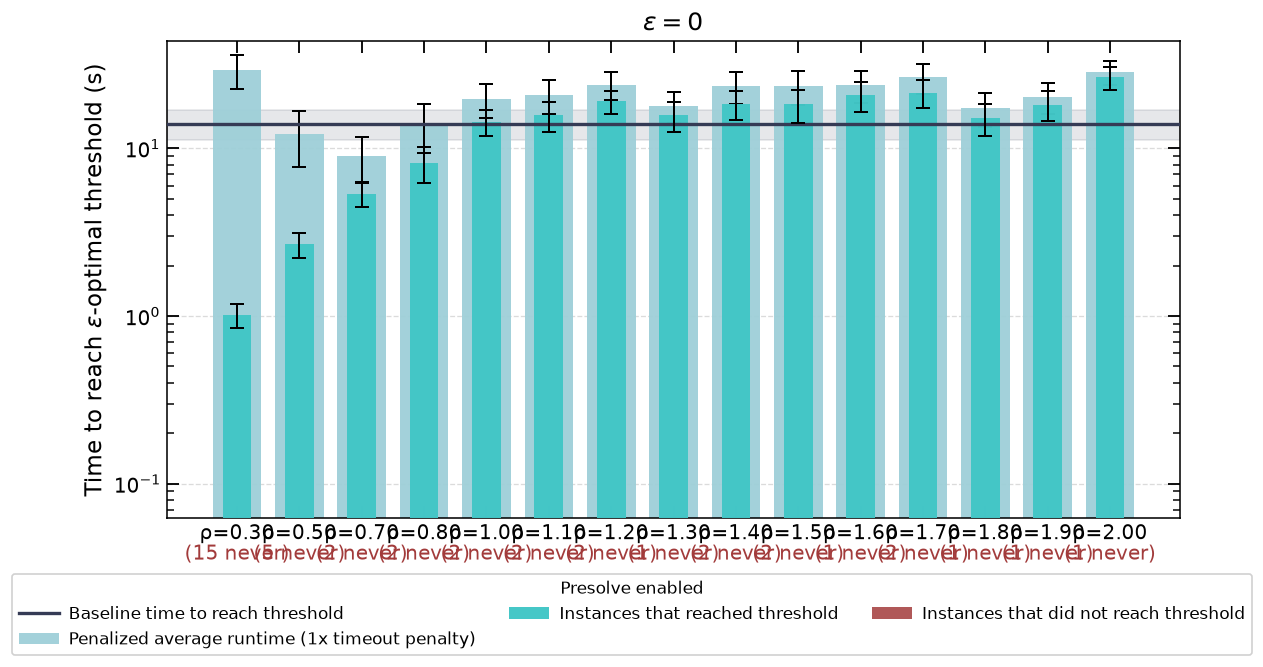

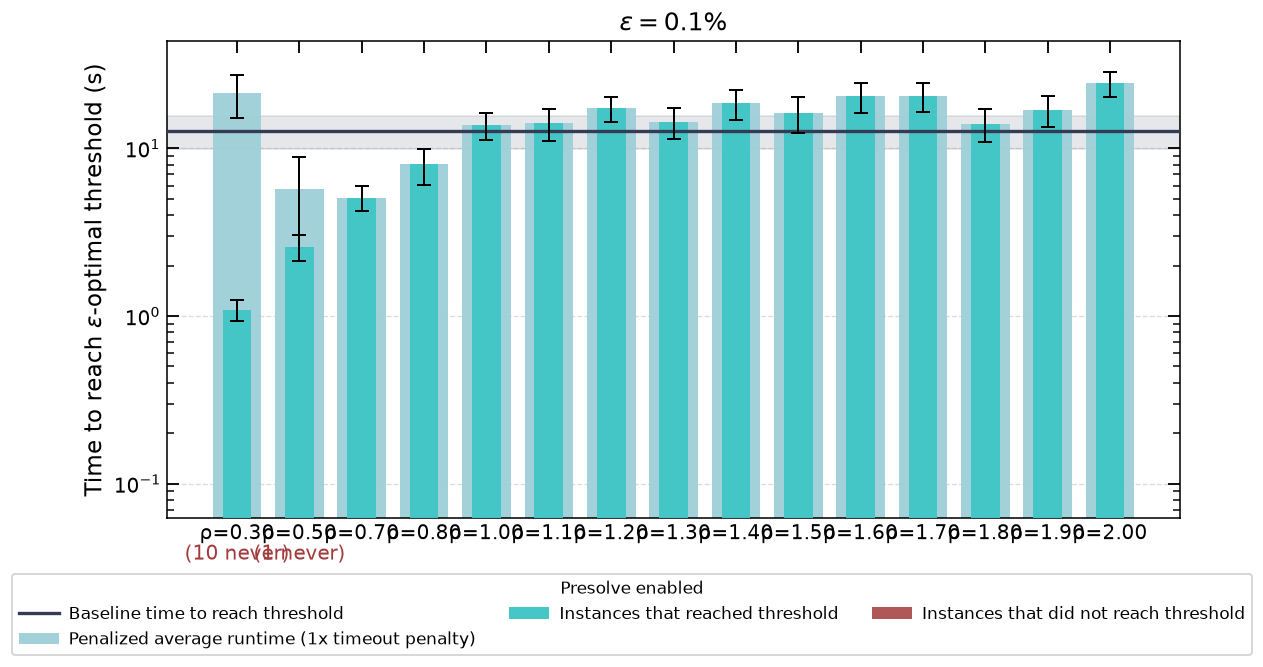

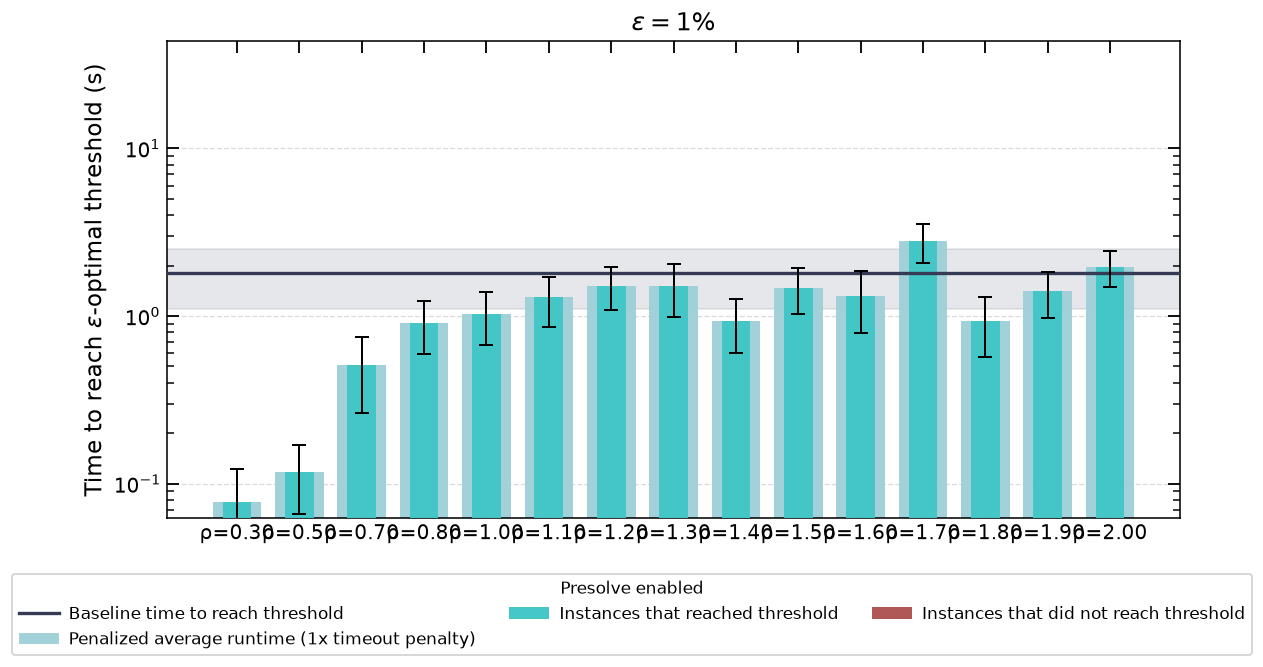

In [2]:
quantum_summary_df = load_summary_data(
    n=N,
    family="quantum",
    layers=QUANTUM_LAYER,
    results_dir=RESULTS_DIR,
)
quantum_traj_by_presolve = load_trajectory_data(
    n=N,
    family="quantum",
    layers=QUANTUM_LAYER,
    results_dir=RESULTS_DIR,
)
quantum_pre = prepare_penalty_metrics(quantum_summary_df)

plot_ratio_minus_one(quantum_pre, quantum_cfg)
plt.show()

quantum_hit_df = prepare_hit_time_metrics(
    quantum_summary_df,
    quantum_traj_by_presolve,
    quantum_cfg,
    THRESHOLDS_TO_PLOT,
    penalty_factor=PAR_FACTOR,
)
quantum_selected_hit_df = quantum_hit_df[quantum_hit_df["presolve"] == PRESOLVE].copy()
quantum_shared_y_limits = (
    compute_hit_time_plot_limits(
        quantum_selected_hit_df,
        presolve=PRESOLVE,
        thresholds=THRESHOLDS_TO_PLOT,
        penalty_filter=PENALTY_FILTER,
    )
    if LOG_TIME_AXIS
    else None
)

for threshold in THRESHOLDS_TO_PLOT:
    plot_hit_time_vs_penalty(
        quantum_selected_hit_df,
        quantum_cfg,
        presolve=PRESOLVE,
        thresholds=[threshold],
        penalty_filter=PENALTY_FILTER,
        y_log=LOG_TIME_AXIS,
        y_limits=quantum_shared_y_limits,
    )
    plt.show()


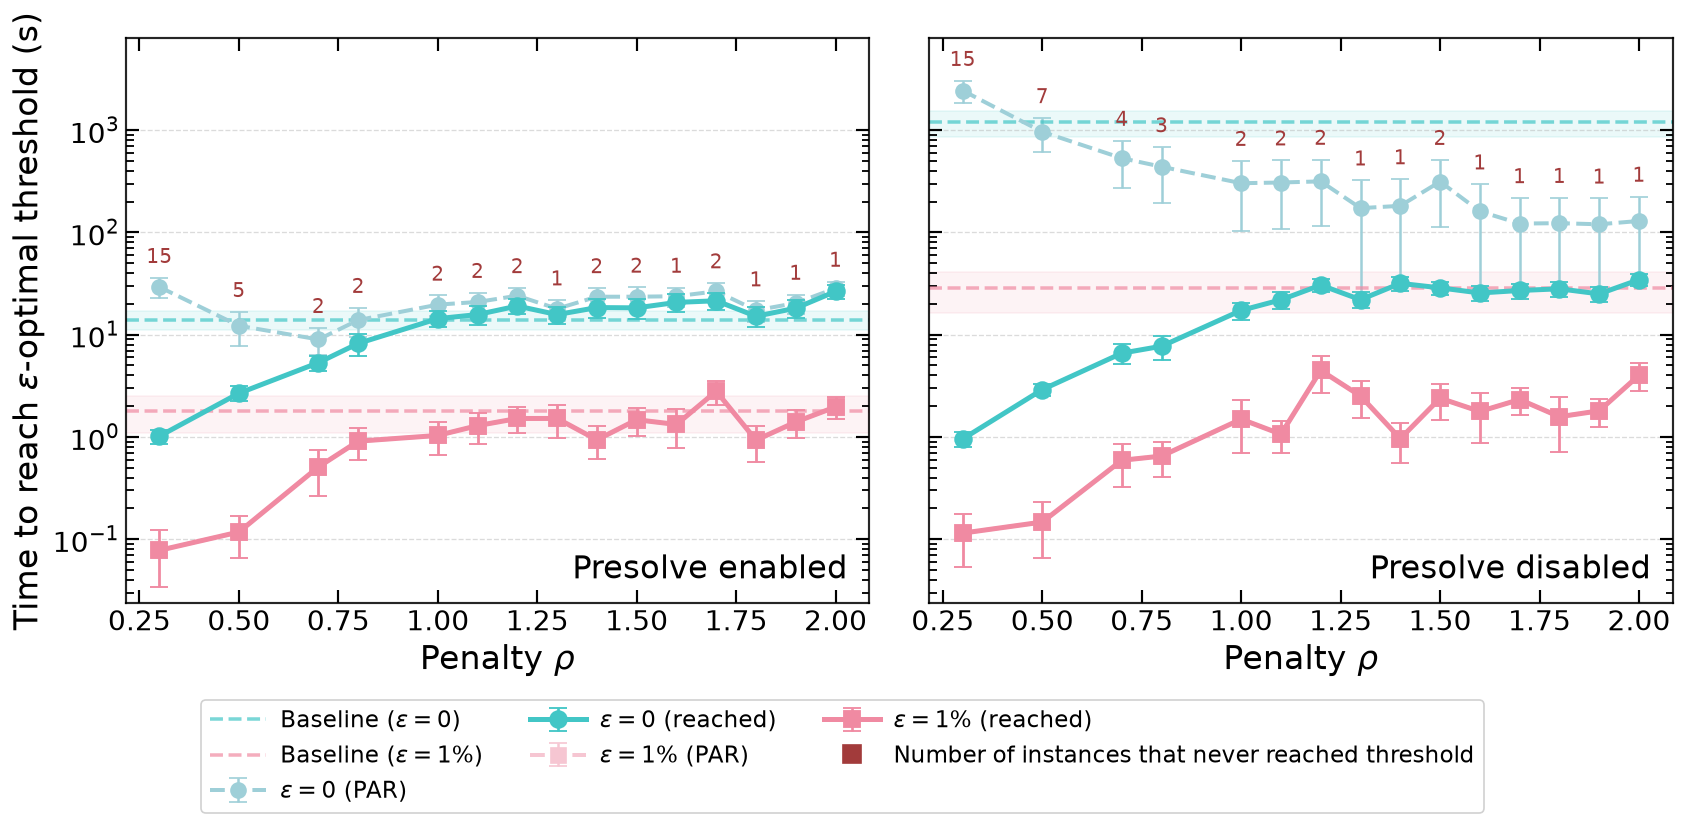

In [3]:
# Combined line-plot version of the bar charts above: both eps=0 and eps=1%
# on the same axes, presolve enabled (left) vs disabled (right) side by side.
fig_par_side = plot_hit_time_lines_side_by_side_presolve(
    quantum_hit_df,
    quantum_cfg,
    thresholds=LINE_EPS_THRESHOLDS,
    penalty_filter=PENALTY_FILTER,
    y_log=LOG_TIME_AXIS,
)
plt.show()

## Quantum Single-Seed MIPSol Trajectory


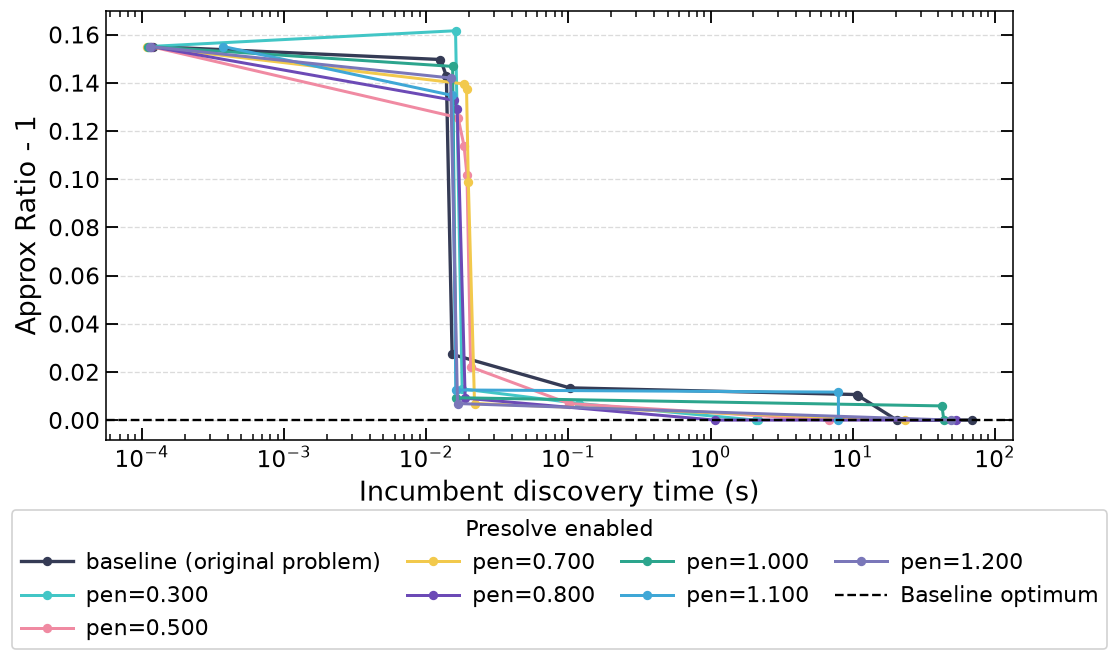

In [4]:
plot_mipsol_ratio_minus_one(
    traj_df=quantum_traj_by_presolve[PRESOLVE],
    cfg=quantum_cfg,
    presolve=PRESOLVE,
    mode="single",
    seed=TRAJ_SEED,
    penalty_filter=TRAJ_PENALTY_FILTER,
    value_col=MIPSOL_VALUE_COL,
)
plt.show()

## Quantum Scaling Across Problem Sizes


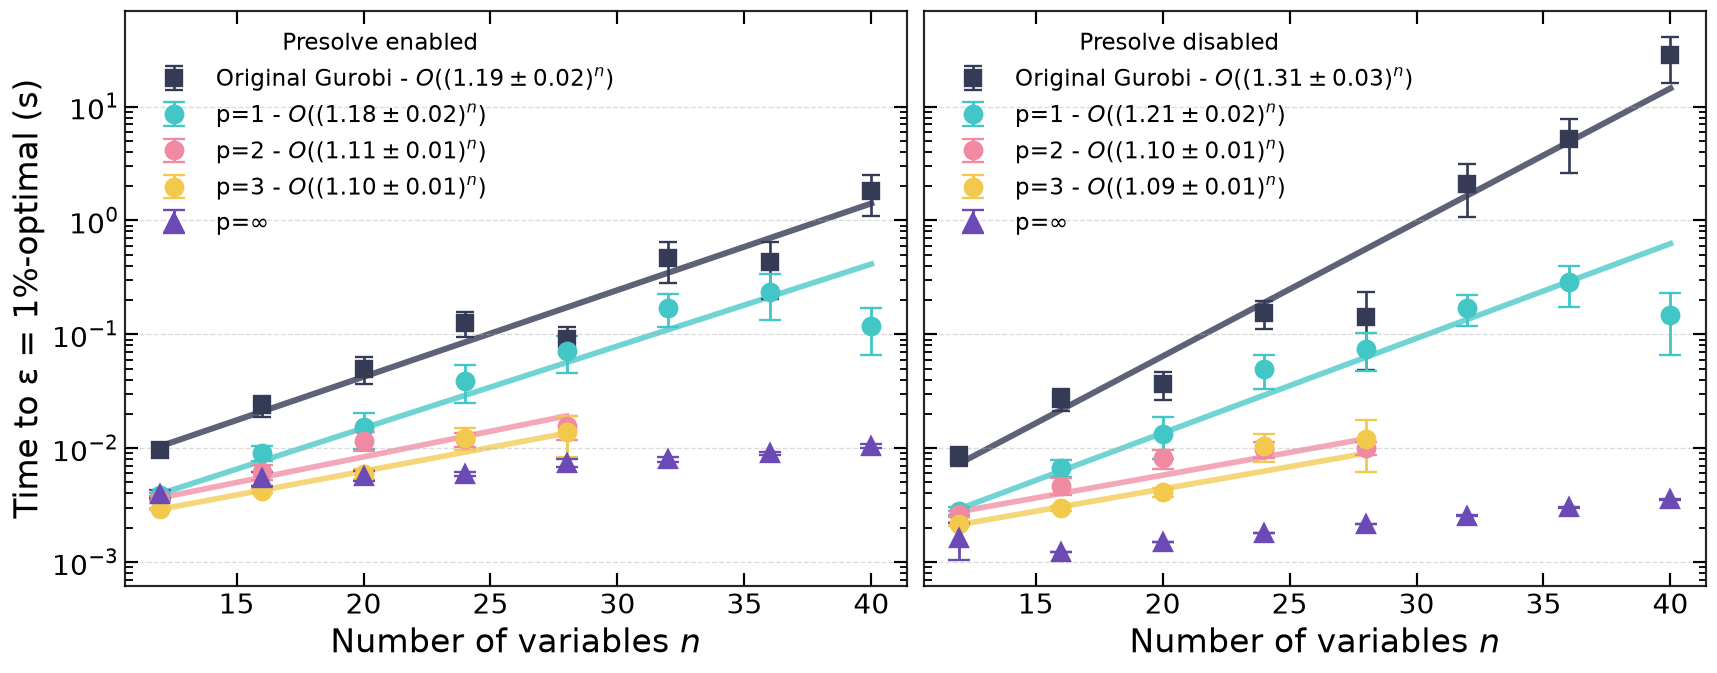

In [5]:
# Side-by-side quantum scaling: presolve enabled (left) vs disabled (right).
# Self-contained (loads its own on/off data) so it doesn't depend on the
# global PRESOLVE toggle.
quantum_side_on_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_side_on_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_side_off_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=False,
    results_dir=RESULTS_DIR,
)
quantum_side_off_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=False,
    results_dir=RESULTS_DIR,
)

if INCLUDE_P_INF:
    quantum_side_on_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_ON,
        presolve=True,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_side_off_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_OFF,
        presolve=False,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_side_on_df = pd.concat([quantum_side_on_df, quantum_side_on_inf_df], ignore_index=True)
    quantum_side_off_df = pd.concat([quantum_side_off_df, quantum_side_off_inf_df], ignore_index=True)

quantum_side_combined_df = pd.concat([quantum_side_on_df, quantum_side_off_df], ignore_index=True)
quantum_side_combined_traj_df = pd.concat([quantum_side_on_traj_df, quantum_side_off_traj_df], ignore_index=True)

fig_side = plot_layer_comparison_side_by_side_presolve(
    summary_df=quantum_side_combined_df,
    layers_list=QUANTUM_COMPARE_PARAMS,
    traj_df=quantum_side_combined_traj_df,
    eps_threshold=EPS_THRESHOLD,
    y_log=True,
    penalty_strategy="fixed",
)
plt.show()

# quantum_compare_df/traj_df (toggle-based on PRESOLVE) feed the "Combined
# Quantum and Classical Scaling" section further down — reuse the on/off data
# already loaded above instead of loading it a third time.
quantum_compare_df = quantum_side_on_df if PRESOLVE else quantum_side_off_df
quantum_compare_traj_df = quantum_side_on_traj_df if PRESOLVE else quantum_side_off_traj_df

## Quantum Scaling — Penalty Strategies (Oracle vs Cross-Validated)

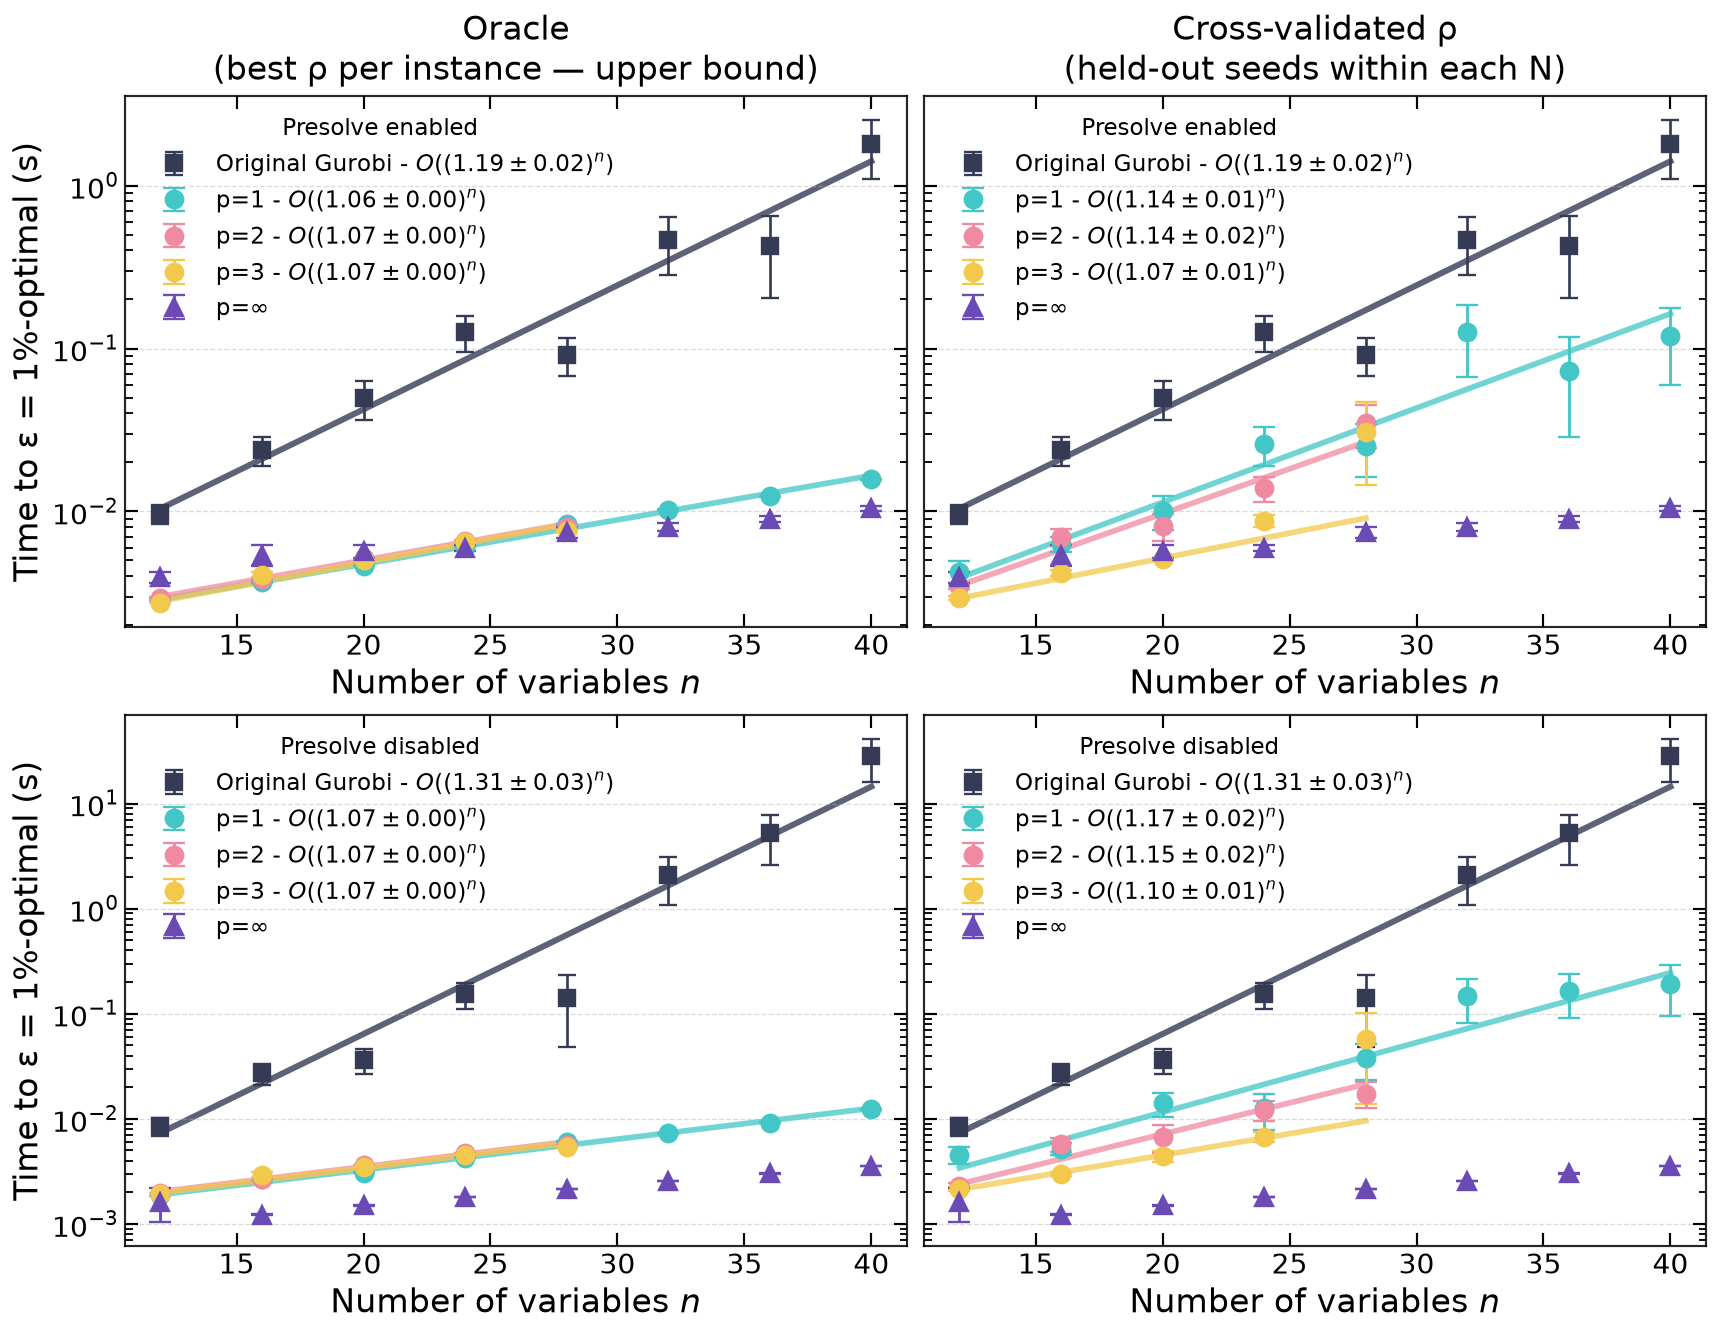

In [6]:
# Combined scaling grid: rows = presolve on/off, cols = oracle/cross-validated
# strategy, eps=1% only. Self-contained (loads its own on/off data) so it
# doesn't depend on whatever the global PRESOLVE toggle happens to be set to.
quantum_grid_on_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_grid_on_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_grid_off_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=False,
    results_dir=RESULTS_DIR,
)
quantum_grid_off_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=False,
    results_dir=RESULTS_DIR,
)

if INCLUDE_P_INF:
    quantum_grid_on_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_ON,
        presolve=True,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_grid_off_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_OFF,
        presolve=False,
        results_dir=RESULTS_DIR,
        data_root=REPO_ROOT / "one_equality_new" / "complete_random",
    )
    quantum_grid_on_df = pd.concat([quantum_grid_on_df, quantum_grid_on_inf_df], ignore_index=True)
    quantum_grid_off_df = pd.concat([quantum_grid_off_df, quantum_grid_off_inf_df], ignore_index=True)

quantum_grid_combined_df = pd.concat([quantum_grid_on_df, quantum_grid_off_df], ignore_index=True)
quantum_grid_combined_traj_df = pd.concat([quantum_grid_on_traj_df, quantum_grid_off_traj_df], ignore_index=True)

fig_grid = plot_layer_comparison_grid_by_presolve(
    summary_df=quantum_grid_combined_df,
    layers_list=QUANTUM_COMPARE_PARAMS,
    traj_df=quantum_grid_combined_traj_df,
    eps_threshold=EPS_THRESHOLD,
    y_log=True,
)
plt.savefig(REPO_ROOT / "scaling_penalty_strategies.png", dpi=150, bbox_inches="tight")
plt.show()

## Classical Penalty Analysis


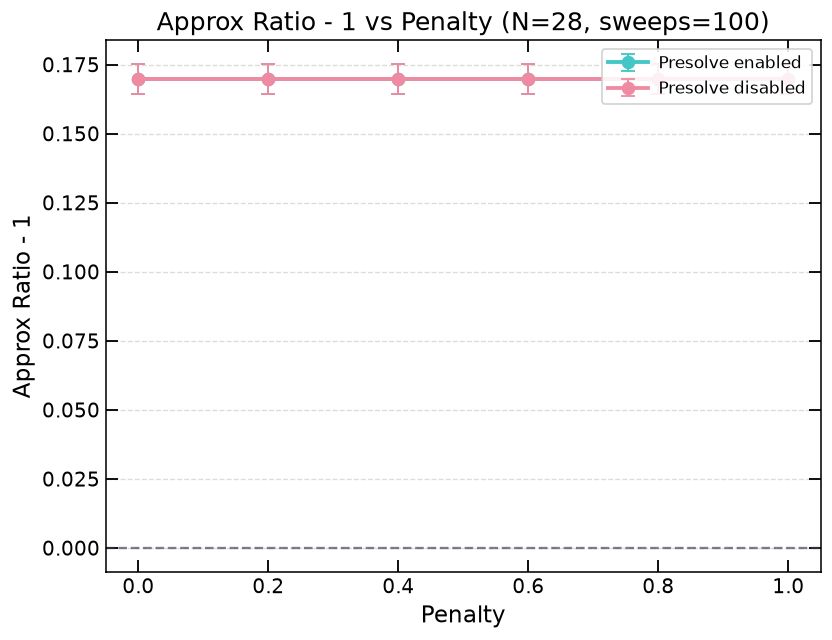

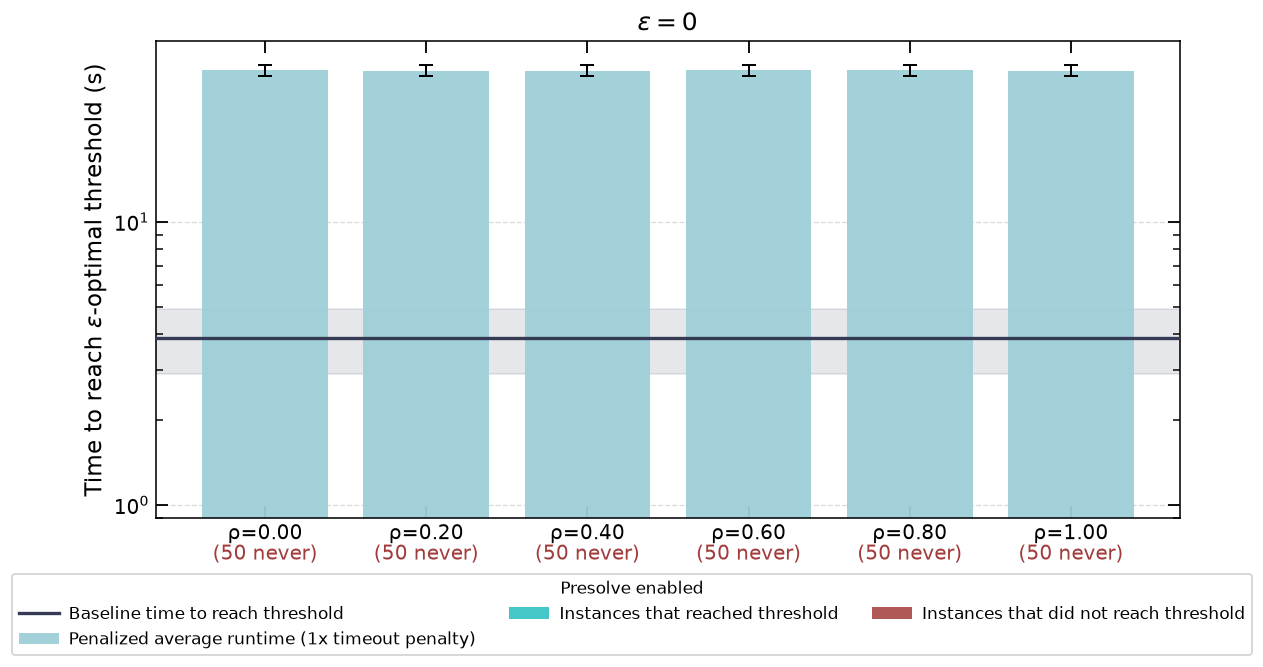

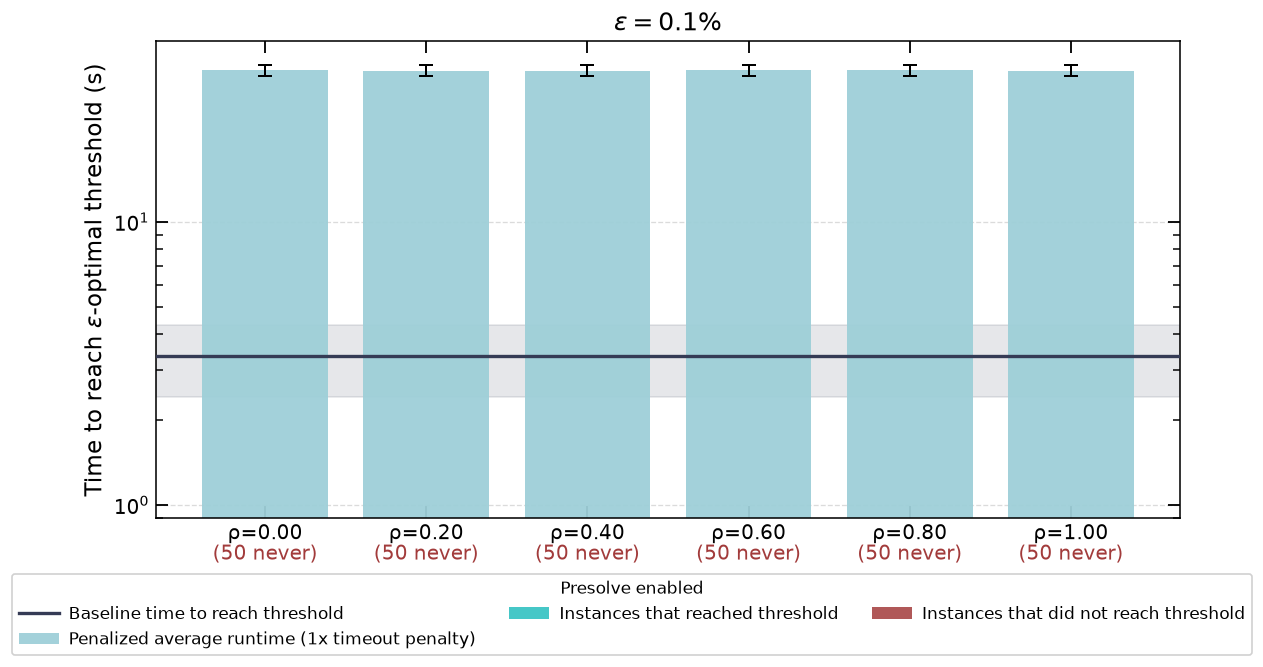

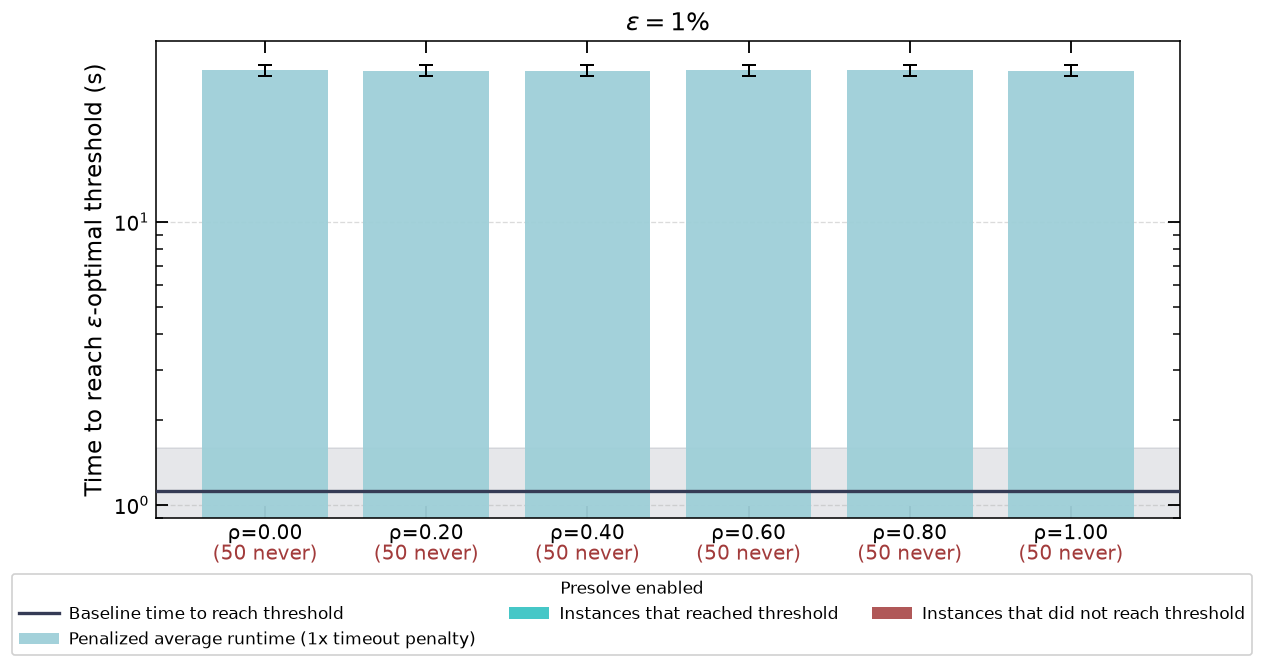

In [7]:
classical_summary_df = load_summary_data(
    n=CLASSICAL_N,
    family="classical",
    sweeps=CLASSICAL_SWEEP,
    results_dir=RESULTS_DIR,
)
classical_traj_by_presolve = load_trajectory_data(
    n=CLASSICAL_N,
    family="classical",
    sweeps=CLASSICAL_SWEEP,
    results_dir=RESULTS_DIR,
)
classical_pre = prepare_penalty_metrics(classical_summary_df)

plot_ratio_minus_one(classical_pre, classical_cfg)
plt.show()

classical_hit_df = prepare_hit_time_metrics(
    classical_summary_df,
    classical_traj_by_presolve,
    classical_cfg,
    THRESHOLDS_TO_PLOT,
    penalty_factor=PAR_FACTOR,
)
classical_selected_hit_df = classical_hit_df[classical_hit_df["presolve"] == PRESOLVE].copy()
classical_shared_y_limits = (
    compute_hit_time_plot_limits(
        classical_selected_hit_df,
        presolve=PRESOLVE,
        thresholds=THRESHOLDS_TO_PLOT,
        penalty_filter=PENALTY_FILTER,
    )
    if LOG_TIME_AXIS
    else None
)

for threshold in THRESHOLDS_TO_PLOT:
    plot_hit_time_vs_penalty(
        classical_selected_hit_df,
        classical_cfg,
        presolve=PRESOLVE,
        thresholds=[threshold],
        penalty_filter=PENALTY_FILTER,
        y_log=LOG_TIME_AXIS,
        y_limits=classical_shared_y_limits,
    )
    plt.show()

## Classical Single-Seed MIPSol Trajectory


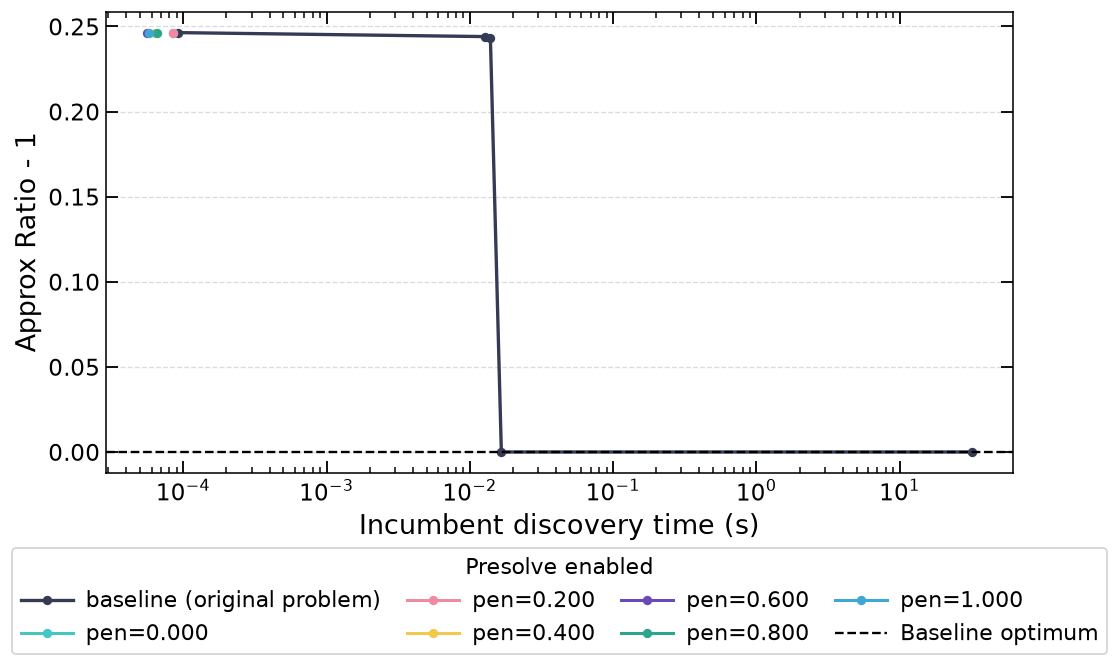

In [8]:
plot_mipsol_ratio_minus_one(
    traj_df=classical_traj_by_presolve[PRESOLVE],
    cfg=classical_cfg,
    presolve=PRESOLVE,
    mode="single",
    seed=TRAJ_SEED,
    penalty_filter=TRAJ_PENALTY_FILTER,
    value_col=MIPSOL_VALUE_COL,
)
plt.show()

## Classical Scaling Across Problem Sizes


Classical scaling uses N = [12, 16, 20, 24, 28, 32]


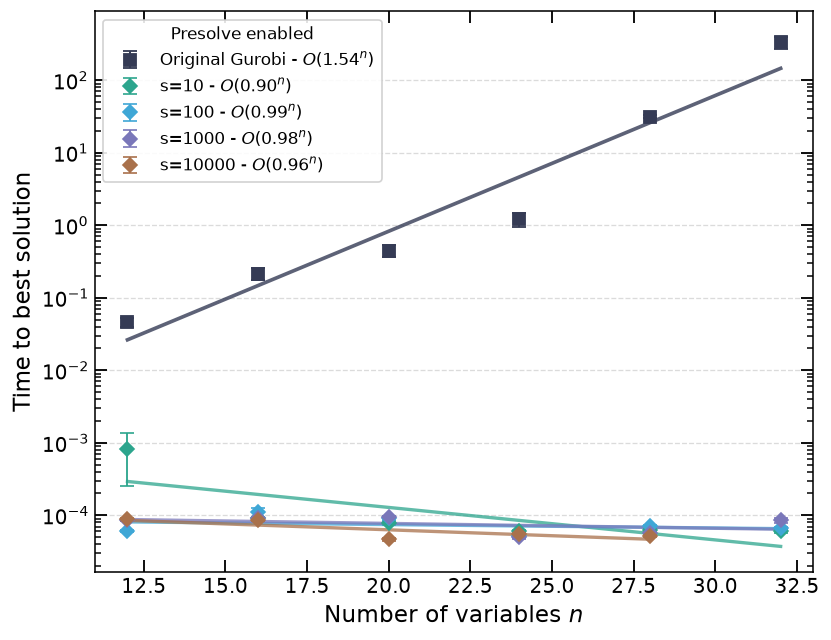

In [9]:
print(f"Classical scaling uses N = {CLASSICAL_SCALING_SIZES}")
classical_compare_df = load_family_comparison_data(
    problem_sizes=CLASSICAL_SCALING_SIZES,
    family="classical",
    param_values=CLASSICAL_SWEEPS,
    presolve=PRESOLVE,
    results_dir=RESULTS_DIR,
)

plot_family_param_comparison(
    summary_df=classical_compare_df,
    family="classical",
    param_values=CLASSICAL_SWEEPS,
    presolve=PRESOLVE,
    metric=COMPARE_METRIC,
    y_log=True,
)
plt.show()


## Combined Quantum and Classical Scaling


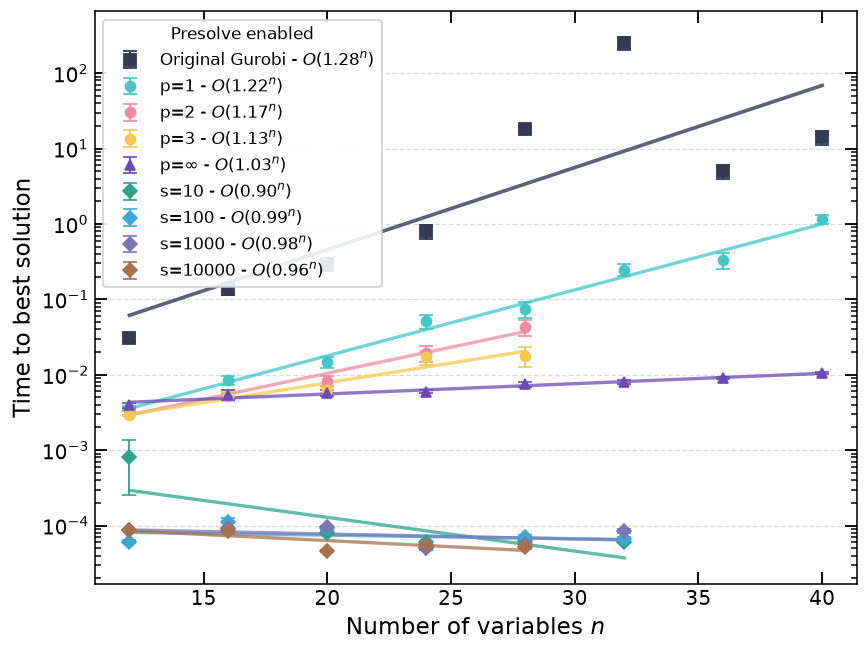

In [10]:
plot_quantum_vs_classical_comparison(
    quantum_df=quantum_compare_df,
    classical_df=classical_compare_df,
    quantum_layers=QUANTUM_COMPARE_PARAMS,
    classical_sweeps=CLASSICAL_SWEEPS,
    presolve=PRESOLVE,
    metric=COMPARE_METRIC,
    y_log=True,
)
plt.show()


## Performance Distribution 

Approximation ratio α = obj_(preconditioned) / obj_(baseline) per seed, for each N and QAOA depth p. α = 1 means the preconditioned solution matches the baseline  solution exactly.

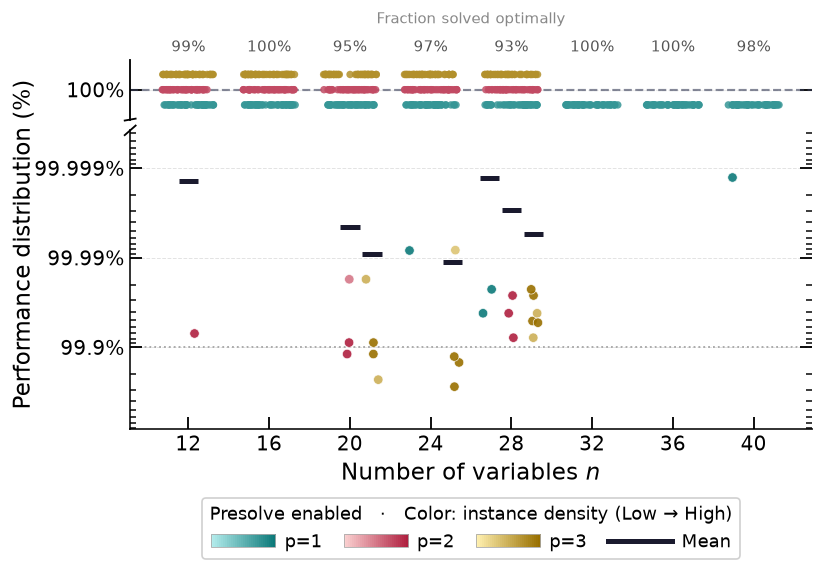

In [11]:
# Build per-p DataFrames for the performance distribution plot
perf_dfs = {}
for _p in QUANTUM_LAYERS:
    _frames = []
    for _n in QUANTUM_SCALING_SIZES:
        _fname = RESULTS_DIR / f"N={_n}_layers={_p}_presolve_{'on' if PRESOLVE else 'off'}.csv"
        try:
            _frames.append(pd.read_csv(_fname))
        except FileNotFoundError:
            pass
    if _frames:
        perf_dfs[f"p={_p}"] = pd.concat(_frames, ignore_index=True)

fig_perf = plot_performance_distribution(perf_dfs, presolve=PRESOLVE)
plt.show()